In [29]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm
import matplotlib.pyplot as plt
import os
from utils import plot_tsne
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Hyperparameters
latent_dim = 128
batch_size = 128
num_epochs_ae = 20
num_epochs_cls = 50
learning_rate = 1e-3
# Early stopping parameters
patience = 5
best_val_loss = float('inf')
patience_counter = 0
checkpoint_dir = 'checkpoints'
patience_classifier = 5
best_val_loss_classifier = float('inf')
patience_counter_classifier = 0
os.makedirs(checkpoint_dir, exist_ok=True)

# Configuration
config = {
    'MNIST': {
        'input_channels': 1,
        'input_size': 28,
        'num_classes': 10,
        'transform': transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.1307,), (0.3081,))
        ]),
        'mean': (0.1307,),
        'std': (0.3081,)
    },
    'CIFAR10': {
        'input_channels': 3,
        'input_size': 32,
        'num_classes': 10,
        'transform': transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ]),
        'mean': (0.5, 0.5, 0.5),
        'std': (0.5, 0.5, 0.5)
    }
}

In [2]:

class Autoencoder(nn.Module): # Gal
    def __init__(self, input_channels, input_size):
        super().__init__()
        self.input_dim = input_channels * input_size ** 2
        self.input_channels = input_channels
        self.input_size = input_size
        self.encoder = nn.Sequential(
            nn.Linear(self.input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, self.input_dim)
        )

    def forward(self, x):
        x = x.view(-1, self.input_dim)
        x = self.encoder(x)
        x = self.decoder(x)
        return x.view(-1, self.input_channels, self.input_size, self.input_size)   



In [32]:
class Classifier(nn.Module):
    def __init__(self, encoder, input_channels, input_size, num_classes):
        super(Classifier, self).__init__()
        self.encoder = encoder
        self.input_channels = input_channels
        self.input_size = input_size
        self.input_dim = input_channels * input_size ** 2
        
        # From your autoencoder, we know the latent dimension is 128
        latent_dim = 128
        
        # Classifier layers
        self.fc1 = nn.Linear(latent_dim, 2048)
        self.bn1 = nn.BatchNorm1d(2048)
        self.fc2 = nn.Linear(2048, 2048)
        self.bn2 = nn.BatchNorm1d(2048)
        self.fc3 = nn.Linear(2048, num_classes)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        # Flatten the input just like in the autoencoder
        x = x.view(-1, self.input_dim)
        
        # Pass through encoder to get latent representation
        x = self.encoder(x)
        
        # Apply classifier layers
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = F.relu(self.bn2(self.fc2(x)))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

In [19]:
def load_dataset(dataset_name):
    cfg = config[dataset_name]
    if dataset_name == 'MNIST':
        train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=cfg['transform'])
        test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=cfg['transform'])
    elif dataset_name == 'CIFAR10':
        train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=cfg['transform'])
        test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=cfg['transform'])
    
    # Split train into train and validation
    train_size = len(train_dataset) - 10000
    train_dataset, val_dataset = random_split(train_dataset, [train_size, 10000])
    
    return train_dataset, val_dataset, test_dataset

def create_data_loaders(train_dataset, val_dataset, test_dataset, batch_size):
    return (
        DataLoader(train_dataset, batch_size=batch_size, shuffle=True),
        DataLoader(val_dataset, batch_size=batch_size, shuffle=False),
        DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    )



In [20]:
def train_autoencoder(model, train_loader, val_loader, device, num_epochs, dataset_name):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    best_val_loss = float('inf')
    patience_counter = 0
    checkpoint_dir = f'checkpoints/{dataset_name}'
    os.makedirs(checkpoint_dir, exist_ok=True)

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        for images, _ in tqdm(train_loader, desc=f"AE Epoch {epoch+1}"):
            images = images.to(device)
            outputs = model(images)
            loss = criterion(outputs, images)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()

        val_loss = evaluate(model, val_loader, device, criterion)
        print(f'AE Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_loss/len(train_loader):.4f}, Val Loss: {val_loss:.4f}')

        # Early stopping and checkpoint logic
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), f'{checkpoint_dir}/ae_best.pth')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered")
                break
        
        
        if isinstance(model, Autoencoder):
            with torch.no_grad():
                dataiter = iter(val_loader)
                images, _ = next(dataiter)
                images = images.to(device)
                outputs = model(images)
                images = images.cpu()
                outputs = outputs.cpu()
                
                # Get image dimensions automatically
                batch_size, channels, height, width = images.shape
                random_indices = torch.randperm(batch_size)[:5]

                # Denormalize images using the config values
                def denormalize(x, dataset_name):
                    mean = torch.tensor(config[dataset_name]['mean']).view(channels, 1, 1)
                    std = torch.tensor(config[dataset_name]['std']).view(channels, 1, 1)
                    return x * std + mean
                
                images_display = denormalize(images, dataset_name)
                outputs_display = denormalize(outputs, dataset_name)
                
                fig, axes = plt.subplots(2, 5, figsize=(12, 4))
                for i in range(5):
                    idx = random_indices[i]
                    if channels == 1:
                        axes[0, i].imshow(images_display[idx].squeeze(), cmap='gray')
                        axes[0, i].axis('off')
                        axes[1, i].imshow(outputs_display[idx].squeeze(), cmap='gray')
                        axes[1, i].axis('off')
                    else:
                        axes[0, i].imshow(images_display[idx].permute(1, 2, 0).clamp(0, 1))
                        axes[0, i].axis('off')
                        axes[1, i].imshow(outputs_display[idx].permute(1, 2, 0).clamp(0, 1))
                        axes[1, i].axis('off')
                
                axes[0, 0].set_title('Original', size=14)
                axes[1, 0].set_title('Reconstructed', size=14)
                plt.tight_layout()
                plt.show()
    return model

def train_classifier(model, train_loader, val_loader, device, num_epochs, dataset_name):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    best_val_acc = 0
    patience_counter = 0
    checkpoint_dir = f'checkpoints/{dataset_name}'
    os.makedirs(checkpoint_dir, exist_ok=True)

    for epoch in range(num_epochs):
        model.train()
        train_loss, correct, total = 0, 0, 0
        for images, labels in tqdm(train_loader, desc=f"CLS Epoch {epoch+1}"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        val_acc = evaluate_classifier(model, val_loader, device)
        print(f'CLS Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_loss/len(train_loader):.4f}, Val Acc: {val_acc:.2f}%')

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), f'{checkpoint_dir}/cls_best.pth')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered")
                break
    return model

def evaluate(model, loader, device, criterion):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            outputs = model(images)
            total_loss += criterion(outputs, images).item()
    return total_loss / len(loader)

def evaluate_classifier(model, loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return 100. * correct / total


In [28]:
dataset_name = "MNIST"
cfg = config[dataset_name]
train_dataset, val_dataset, test_dataset = load_dataset(dataset_name)
train_loader, val_loader, test_loader = create_data_loaders(train_dataset, val_dataset, test_dataset, batch_size)


Training Autoencoder on MNIST


AE Epoch 1:   0%|          | 0/391 [00:00<?, ?it/s]

AE Epoch 1: 100%|██████████| 391/391 [00:15<00:00, 24.69it/s]


AE Epoch [1/15] Train Loss: 0.3135, Val Loss: 0.1698


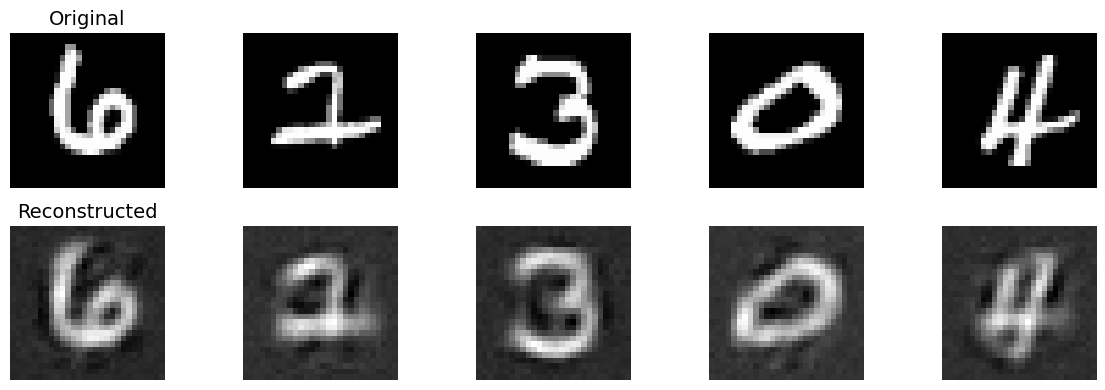

AE Epoch 2: 100%|██████████| 391/391 [00:15<00:00, 25.84it/s]


AE Epoch [2/15] Train Loss: 0.1403, Val Loss: 0.1185


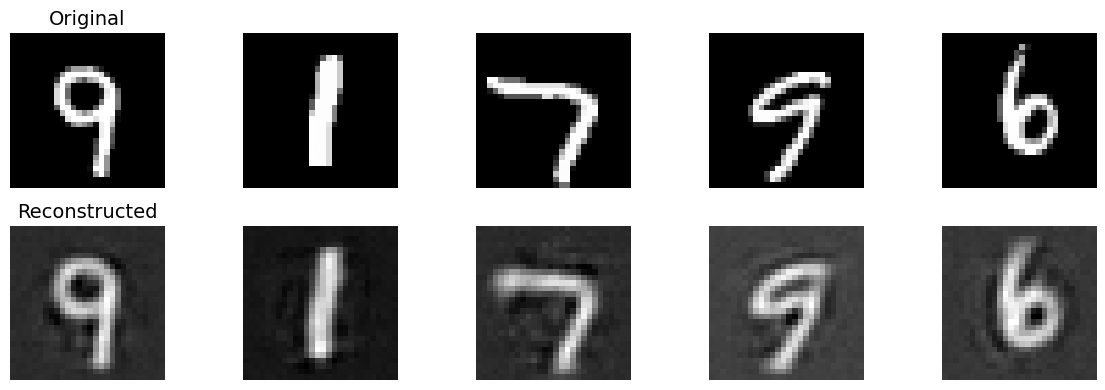

AE Epoch 3: 100%|██████████| 391/391 [00:13<00:00, 29.97it/s]


AE Epoch [3/15] Train Loss: 0.1079, Val Loss: 0.0983


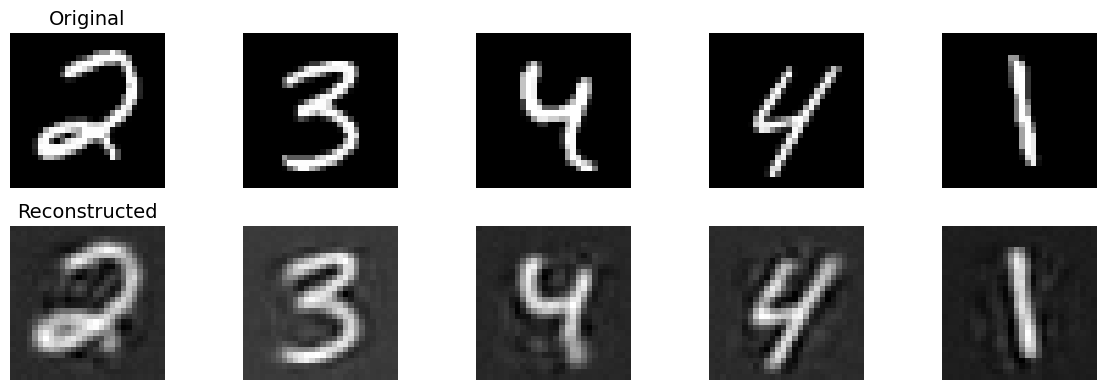

AE Epoch 4: 100%|██████████| 391/391 [00:13<00:00, 29.78it/s]


AE Epoch [4/15] Train Loss: 0.0922, Val Loss: 0.0873


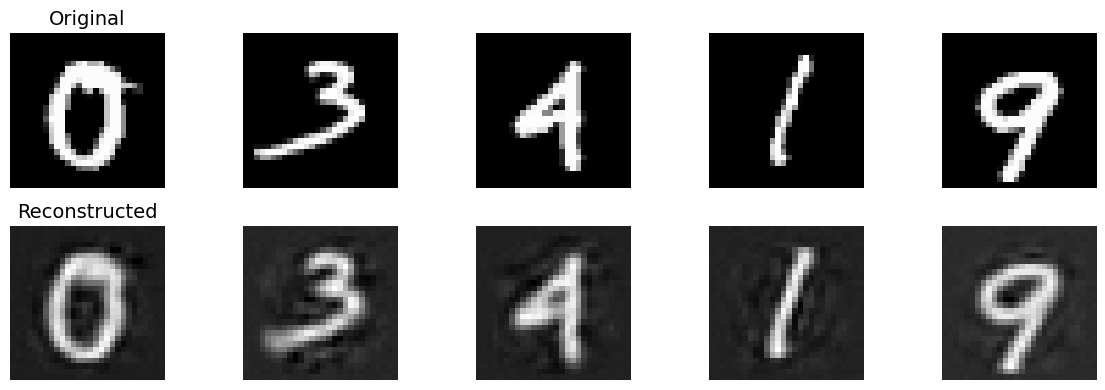

AE Epoch 5: 100%|██████████| 391/391 [00:13<00:00, 29.28it/s]


AE Epoch [5/15] Train Loss: 0.0821, Val Loss: 0.0784


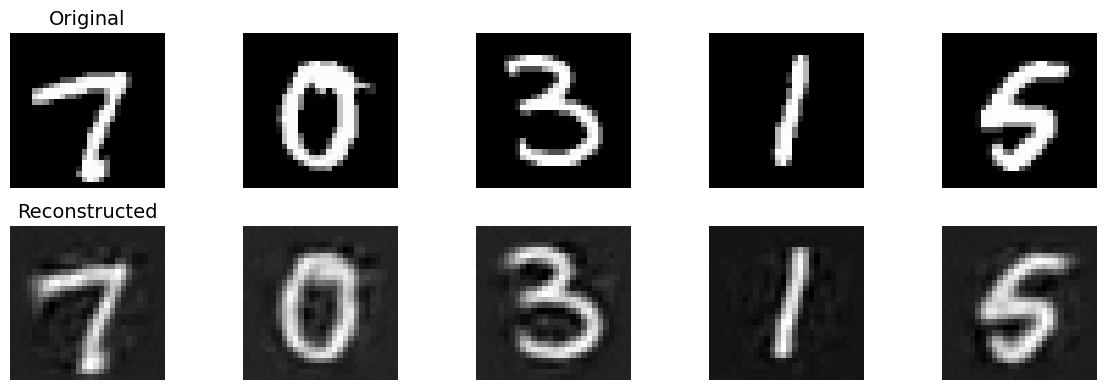

AE Epoch 6: 100%|██████████| 391/391 [00:12<00:00, 30.68it/s]


AE Epoch [6/15] Train Loss: 0.0749, Val Loss: 0.0732


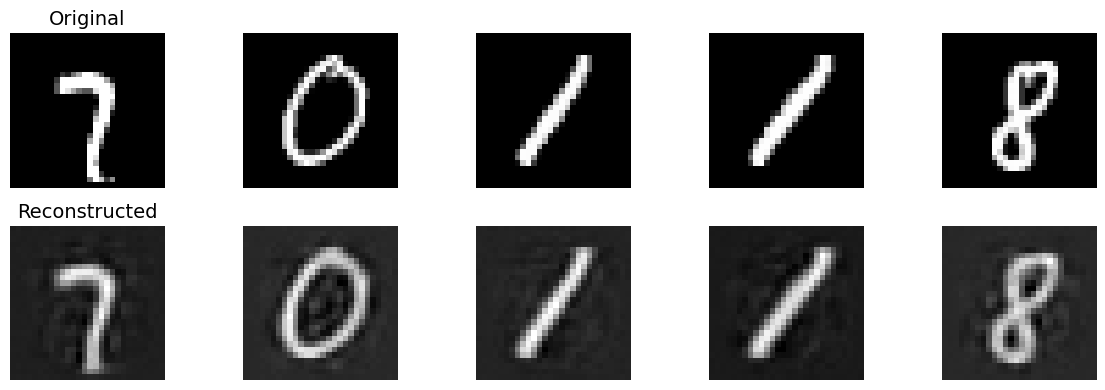

AE Epoch 7: 100%|██████████| 391/391 [00:13<00:00, 29.92it/s]


AE Epoch [7/15] Train Loss: 0.0696, Val Loss: 0.0678


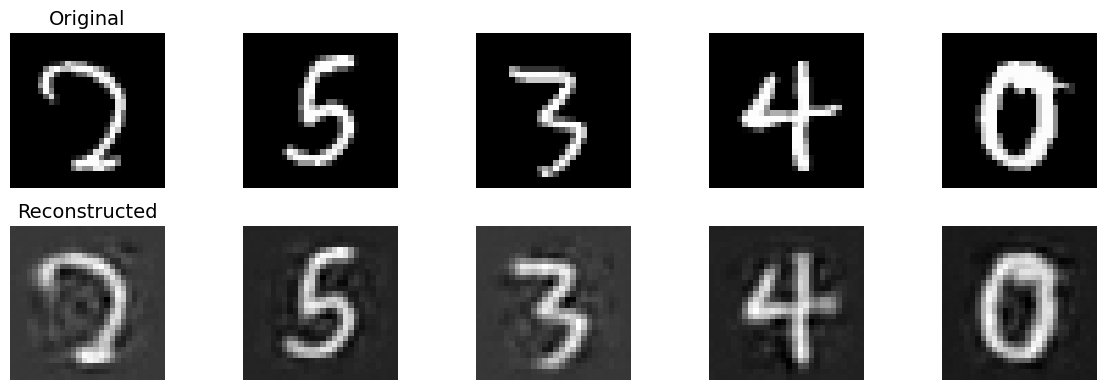

AE Epoch 8: 100%|██████████| 391/391 [00:12<00:00, 30.96it/s]


AE Epoch [8/15] Train Loss: 0.0654, Val Loss: 0.0641


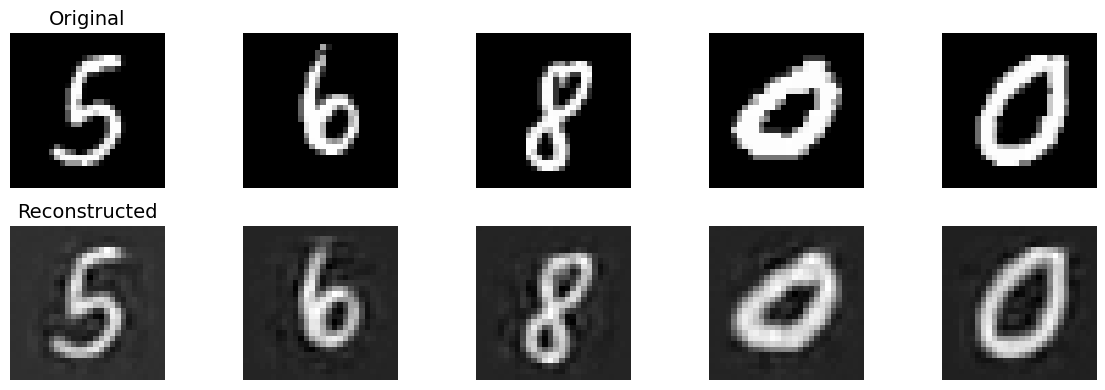

AE Epoch 9: 100%|██████████| 391/391 [00:12<00:00, 30.59it/s]


AE Epoch [9/15] Train Loss: 0.0619, Val Loss: 0.0617


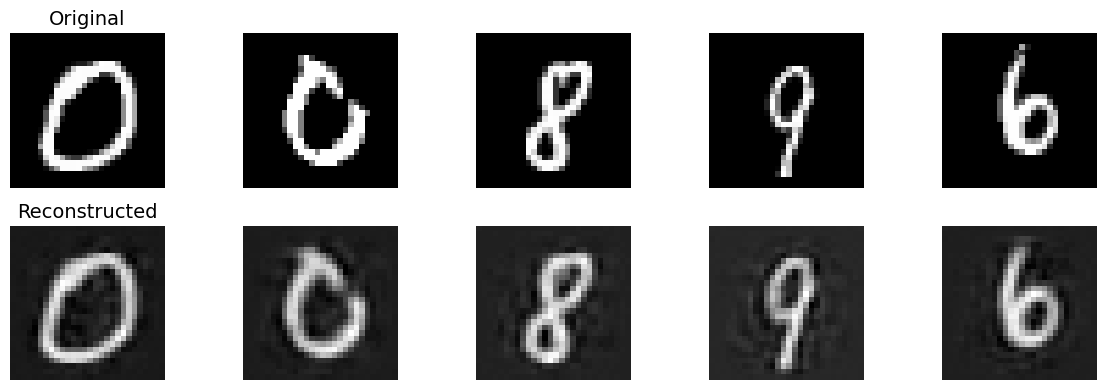

AE Epoch 10: 100%|██████████| 391/391 [00:12<00:00, 30.14it/s]


AE Epoch [10/15] Train Loss: 0.0592, Val Loss: 0.0585


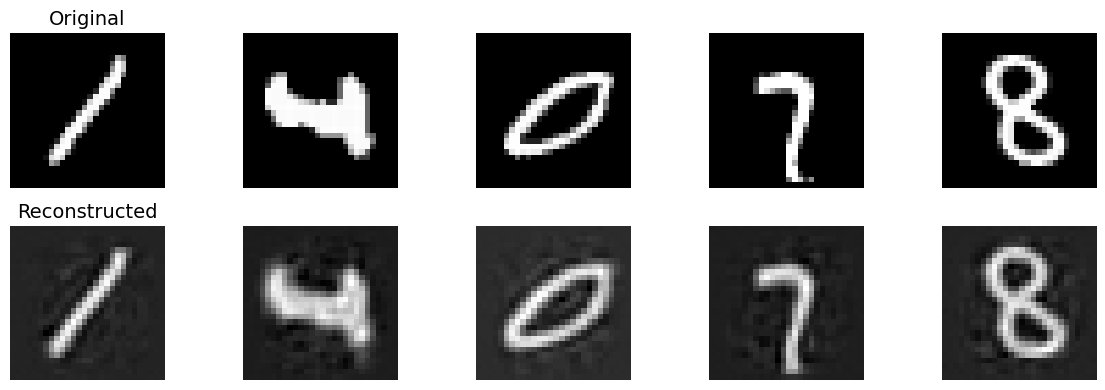

AE Epoch 11: 100%|██████████| 391/391 [00:13<00:00, 29.18it/s]


AE Epoch [11/15] Train Loss: 0.0567, Val Loss: 0.0552


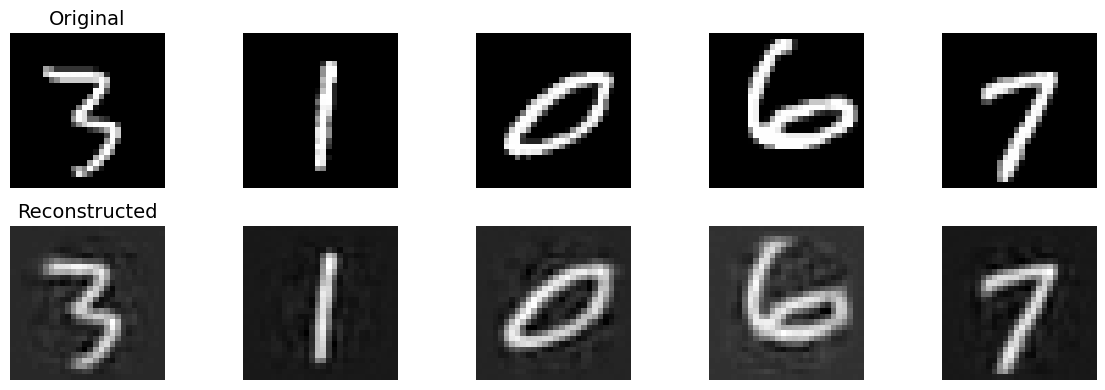

AE Epoch 12: 100%|██████████| 391/391 [00:15<00:00, 25.77it/s]


AE Epoch [12/15] Train Loss: 0.0547, Val Loss: 0.0544


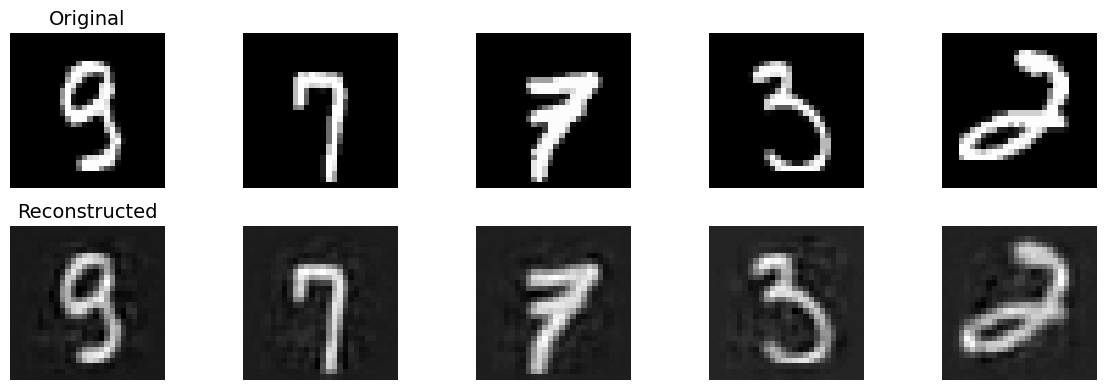

AE Epoch 13: 100%|██████████| 391/391 [00:13<00:00, 28.13it/s]


AE Epoch [13/15] Train Loss: 0.0530, Val Loss: 0.0576


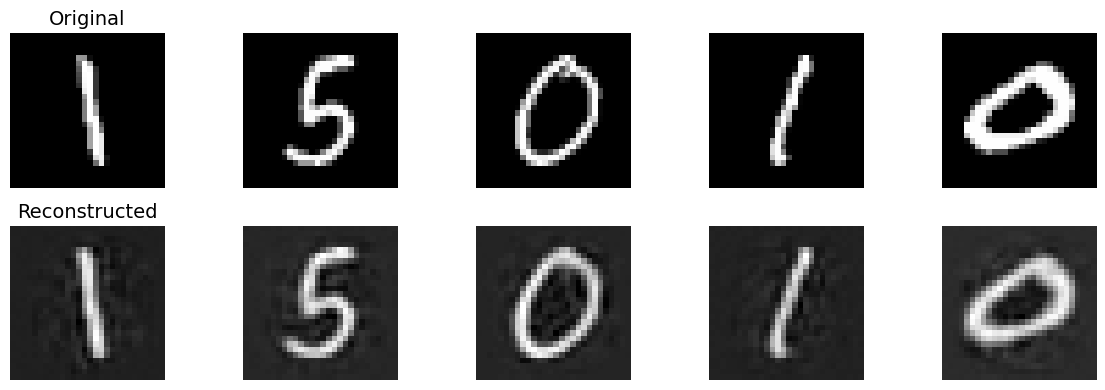

AE Epoch 14: 100%|██████████| 391/391 [00:13<00:00, 28.76it/s]


AE Epoch [14/15] Train Loss: 0.0514, Val Loss: 0.0520


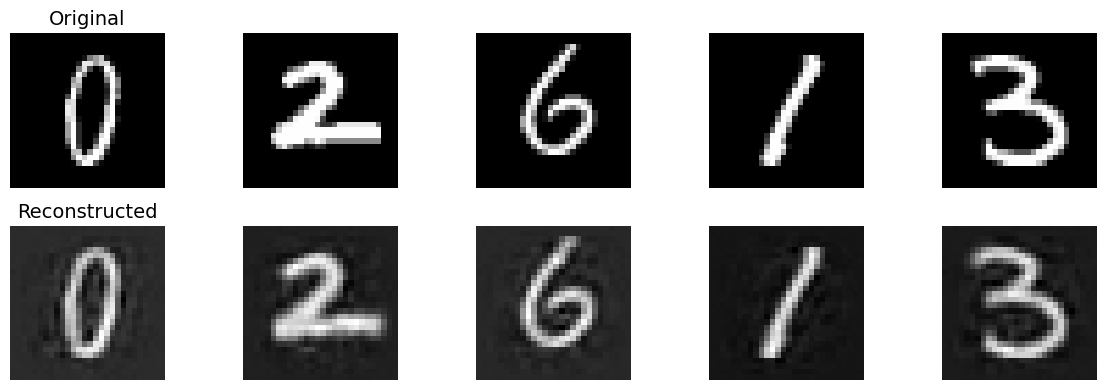

AE Epoch 15: 100%|██████████| 391/391 [00:13<00:00, 29.04it/s]


AE Epoch [15/15] Train Loss: 0.0501, Val Loss: 0.0498


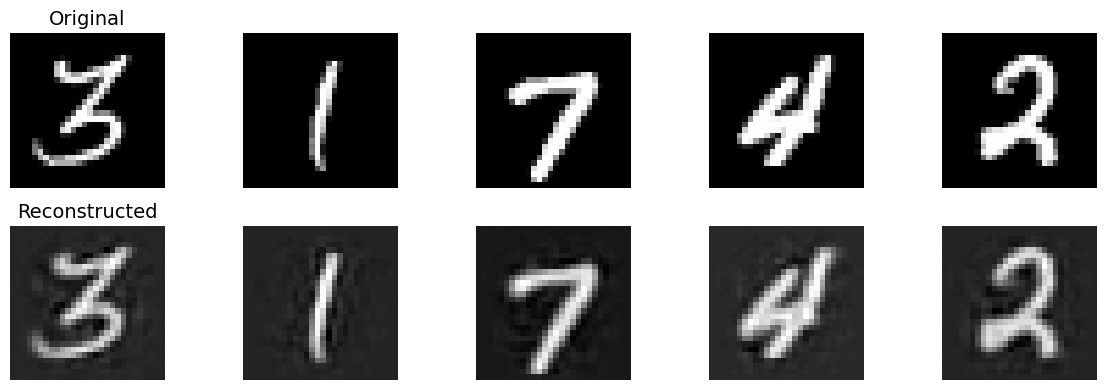

In [29]:
ae = Autoencoder(cfg['input_channels'], cfg['input_size']).to(device)
print(f"Training Autoencoder on {dataset_name}")
ae = train_autoencoder(ae, train_loader, val_loader, device, num_epochs_ae, dataset_name)





In [30]:
ae_test_loss = evaluate(ae, test_loader, device, criterion = nn.MSELoss())
print(f'Test Loss: {ae_test_loss:.4f}')

Test Loss: 0.0489


In [32]:
# Classifier

classifier = Classifier(ae.encoder, ae.input_dim, cfg['num_classes']).to(device)
# classifier = Classifier(ae.encoder, config[dataset_name]['num_classes']).to(device)

for param in classifier.encoder.parameters():
    param.requires_grad = False
print(f"\nTraining Classifier on {dataset_name}")
classifier = train_classifier(classifier, train_loader, val_loader, device, num_epochs_cls, dataset_name)


Training Classifier on MNIST


CLS Epoch 1:   0%|          | 0/391 [00:00<?, ?it/s]

CLS Epoch 1: 100%|██████████| 391/391 [00:13<00:00, 29.88it/s]


CLS Epoch [1/15] Train Loss: 0.2711, Val Acc: 96.49%


CLS Epoch 2: 100%|██████████| 391/391 [00:13<00:00, 29.67it/s]


...

CLS Epoch [13/15] Train Loss: 0.0546, Val Acc: 98.29%


CLS Epoch 14: 100%|██████████| 391/391 [00:12<00:00, 31.13it/s]


CLS Epoch [14/15] Train Loss: 0.0538, Val Acc: 98.39%


CLS Epoch 15: 100%|██████████| 391/391 [00:12<00:00, 30.71it/s]


CLS Epoch [15/15] Train Loss: 0.0487, Val Acc: 98.51%


In [33]:

# Final test
test_acc = evaluate_classifier(classifier, test_loader, device)
print(f'\nFinal Test Accuracy on {dataset_name}: {test_acc:.2f}%')




Final Test Accuracy on MNIST: 98.51%


In [34]:
import importlib
import utils
importlib.reload(utils)
from utils import plot_tsne


In [35]:

# Visualization
plot_tsne(ae.encoder, test_loader, device)


KeyboardInterrupt: 

In [ ]:
####################################

In [6]:
# now for CIFAR10
dataset_name = "CIFAR10"
cfg = config[dataset_name]
train_dataset, val_dataset, test_dataset = load_dataset(dataset_name)
train_loader, val_loader, test_loader = create_data_loaders(train_dataset, val_dataset, test_dataset, batch_size)


Files already downloaded and verified
Files already downloaded and verified


Training Autoencoder on CIFAR10


AE Epoch 1:   0%|          | 0/313 [00:00<?, ?it/s]

AE Epoch 1: 100%|██████████| 313/313 [00:17<00:00, 17.62it/s]


AE Epoch [1/20] Train Loss: 0.0904, Val Loss: 0.0605


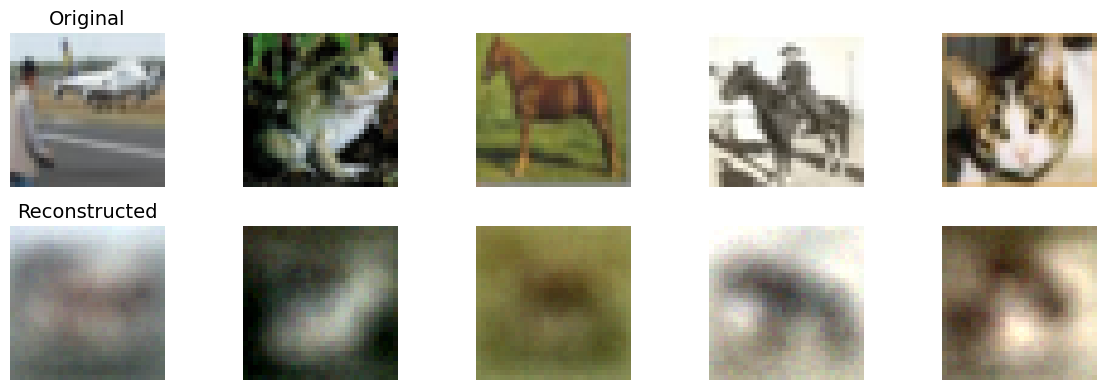

AE Epoch 2: 100%|██████████| 313/313 [00:13<00:00, 22.38it/s]


AE Epoch [2/20] Train Loss: 0.0541, Val Loss: 0.0489


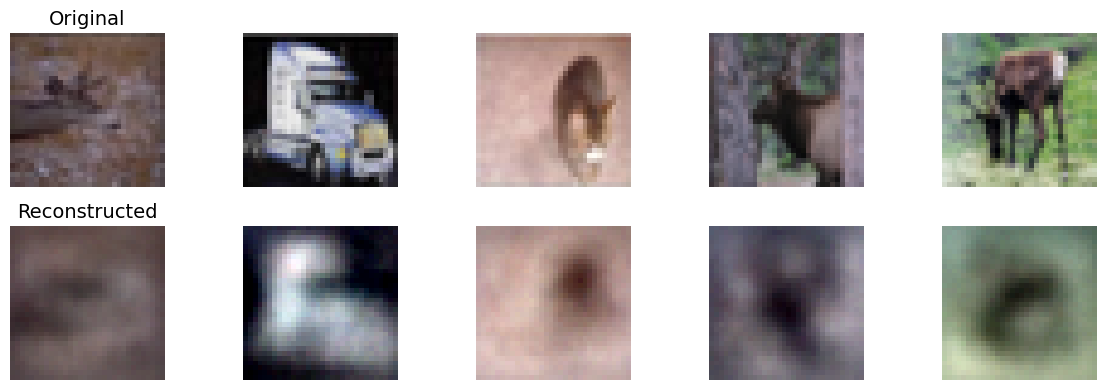

AE Epoch 3: 100%|██████████| 313/313 [00:14<00:00, 22.12it/s]


AE Epoch [3/20] Train Loss: 0.0463, Val Loss: 0.0438


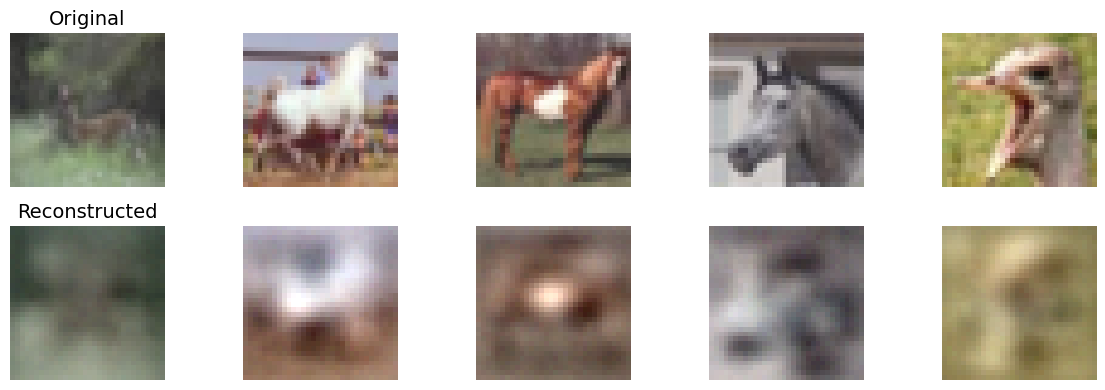

AE Epoch 4: 100%|██████████| 313/313 [00:14<00:00, 22.02it/s]


AE Epoch [4/20] Train Loss: 0.0422, Val Loss: 0.0401


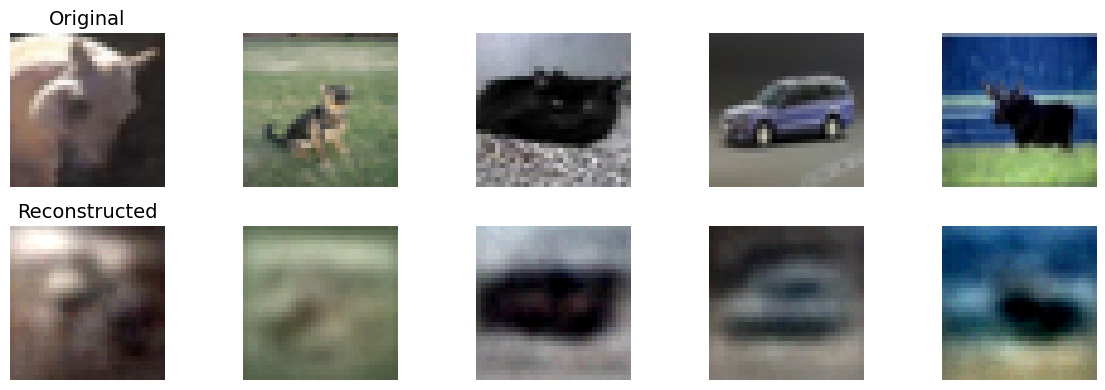

AE Epoch 5: 100%|██████████| 313/313 [00:13<00:00, 23.37it/s]


AE Epoch [5/20] Train Loss: 0.0394, Val Loss: 0.0386


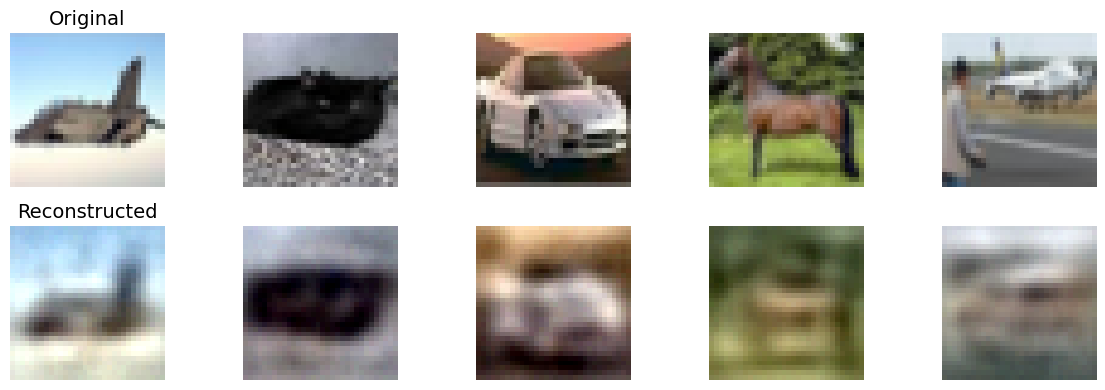

AE Epoch 6: 100%|██████████| 313/313 [00:13<00:00, 23.58it/s]


AE Epoch [6/20] Train Loss: 0.0372, Val Loss: 0.0364


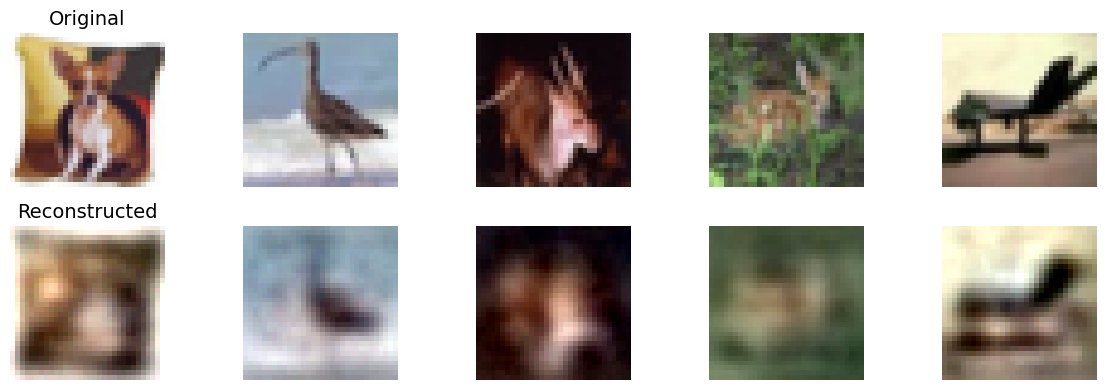

AE Epoch 7: 100%|██████████| 313/313 [00:14<00:00, 21.15it/s]


AE Epoch [7/20] Train Loss: 0.0355, Val Loss: 0.0355


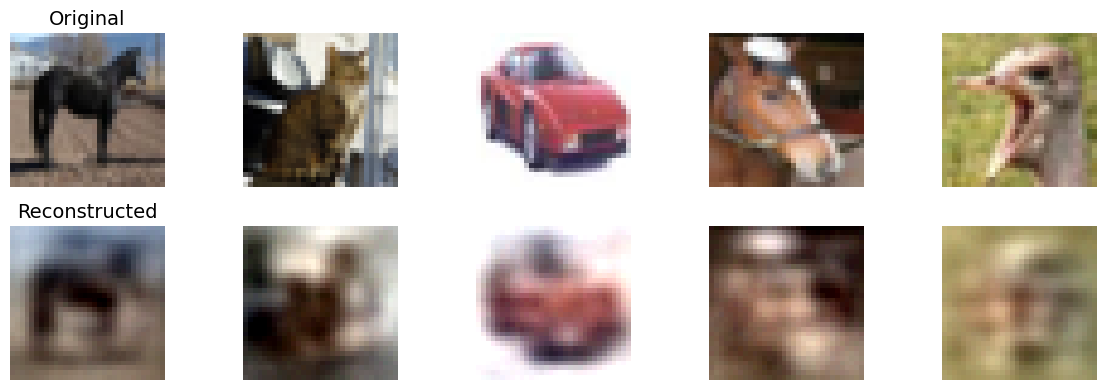

AE Epoch 8: 100%|██████████| 313/313 [00:13<00:00, 23.13it/s]


AE Epoch [8/20] Train Loss: 0.0344, Val Loss: 0.0339


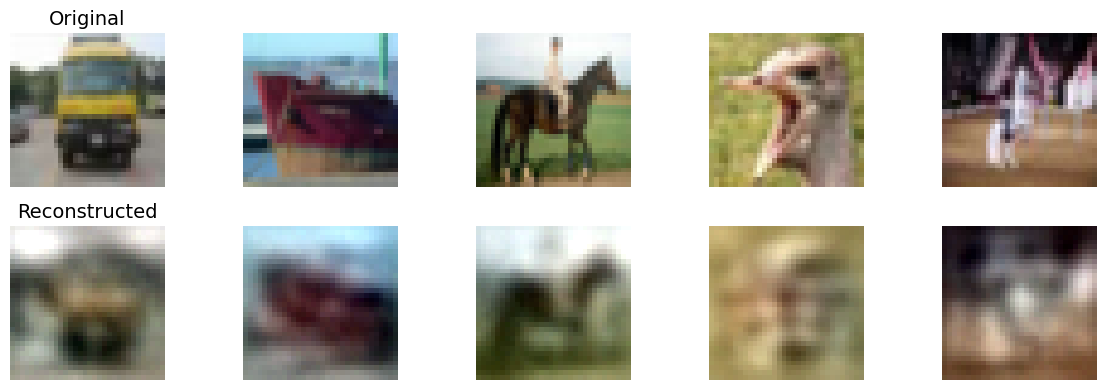

AE Epoch 9: 100%|██████████| 313/313 [00:13<00:00, 23.34it/s]


AE Epoch [9/20] Train Loss: 0.0331, Val Loss: 0.0325


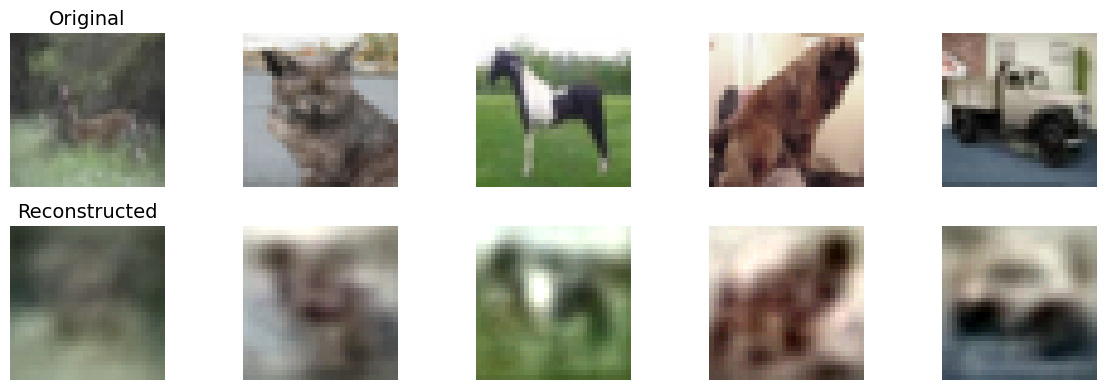

AE Epoch 10: 100%|██████████| 313/313 [00:12<00:00, 24.22it/s]


AE Epoch [10/20] Train Loss: 0.0322, Val Loss: 0.0320


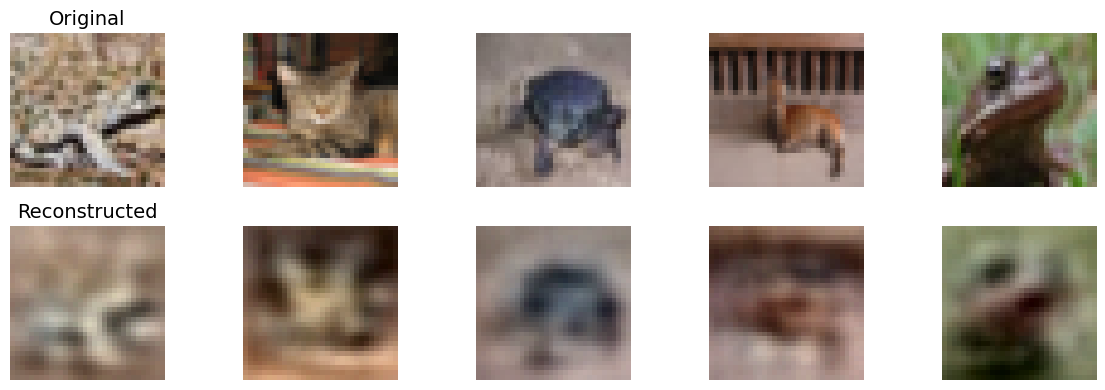

AE Epoch 11: 100%|██████████| 313/313 [00:13<00:00, 24.00it/s]


AE Epoch [11/20] Train Loss: 0.0315, Val Loss: 0.0314


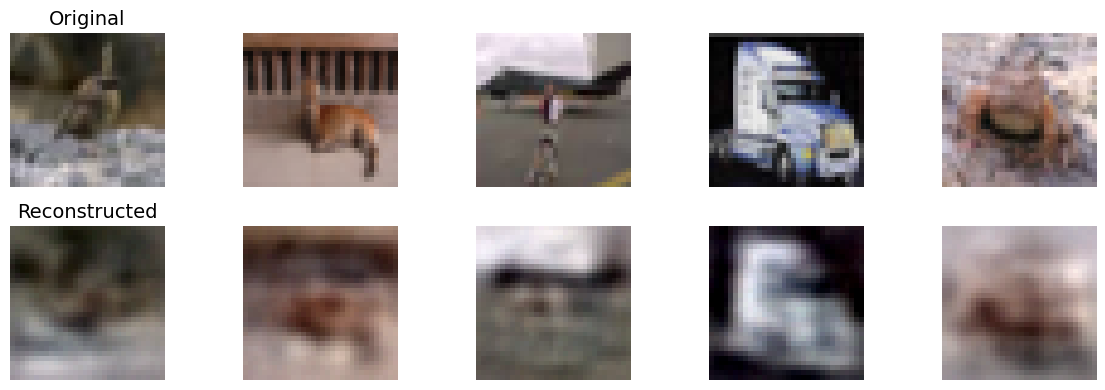

AE Epoch 12: 100%|██████████| 313/313 [00:12<00:00, 24.27it/s]


AE Epoch [12/20] Train Loss: 0.0310, Val Loss: 0.0307


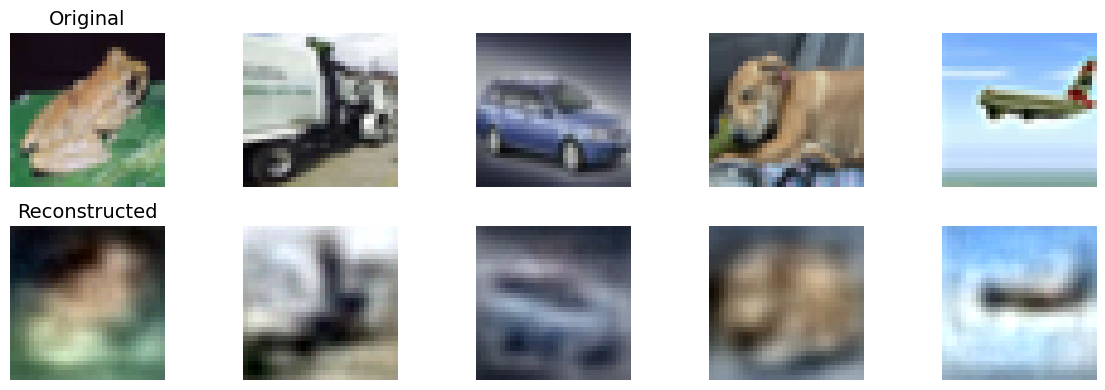

AE Epoch 13: 100%|██████████| 313/313 [00:13<00:00, 23.34it/s]


AE Epoch [13/20] Train Loss: 0.0304, Val Loss: 0.0303


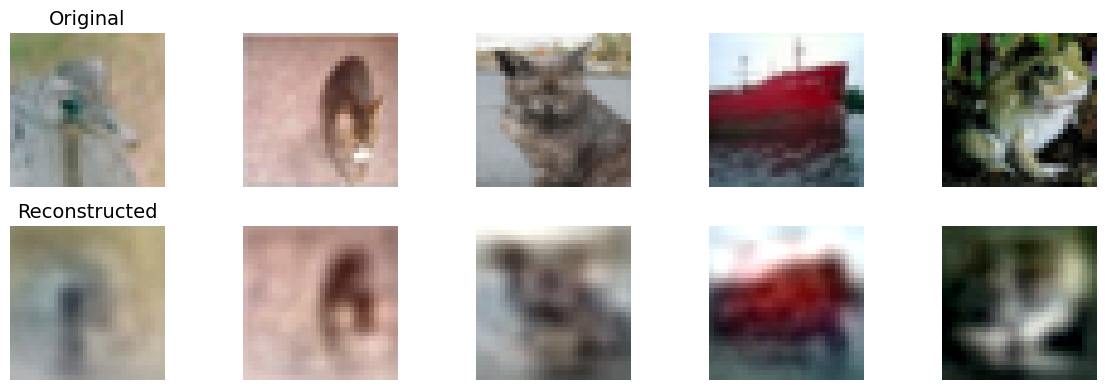

AE Epoch 14: 100%|██████████| 313/313 [00:13<00:00, 23.80it/s]


AE Epoch [14/20] Train Loss: 0.0300, Val Loss: 0.0297


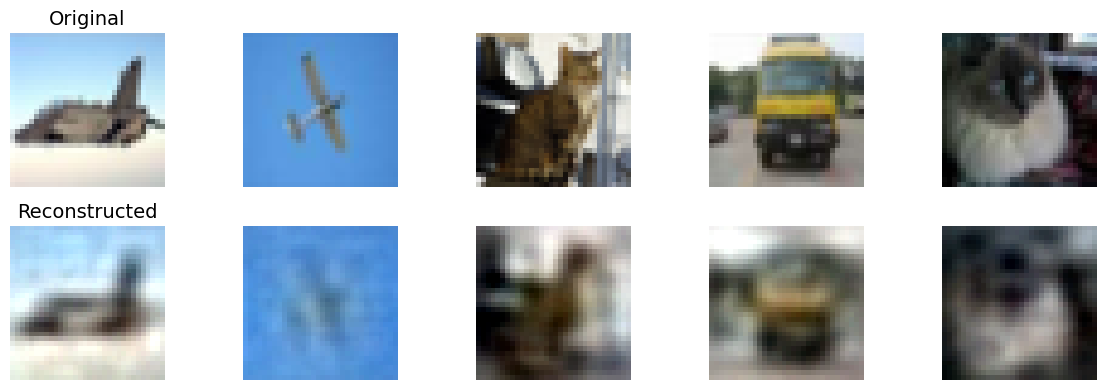

AE Epoch 15: 100%|██████████| 313/313 [00:13<00:00, 23.71it/s]


AE Epoch [15/20] Train Loss: 0.0297, Val Loss: 0.0299


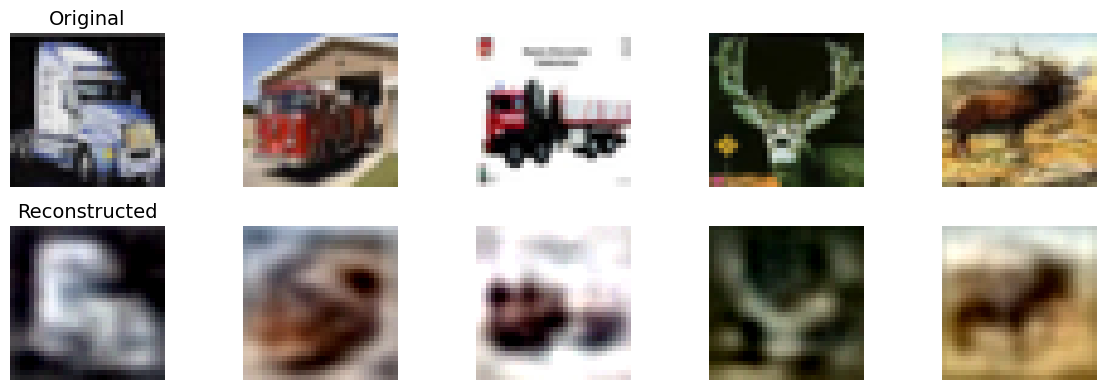

AE Epoch 16: 100%|██████████| 313/313 [00:12<00:00, 24.25it/s]


AE Epoch [16/20] Train Loss: 0.0291, Val Loss: 0.0291


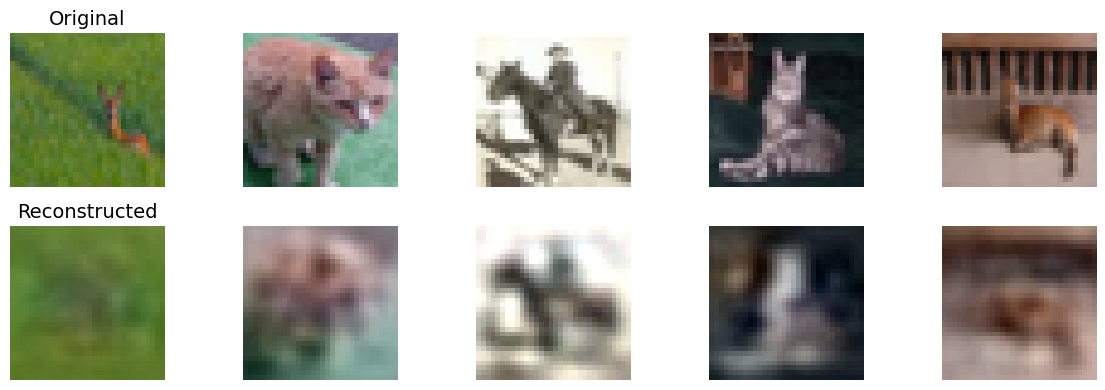

AE Epoch 17: 100%|██████████| 313/313 [00:13<00:00, 23.92it/s]


AE Epoch [17/20] Train Loss: 0.0289, Val Loss: 0.0288


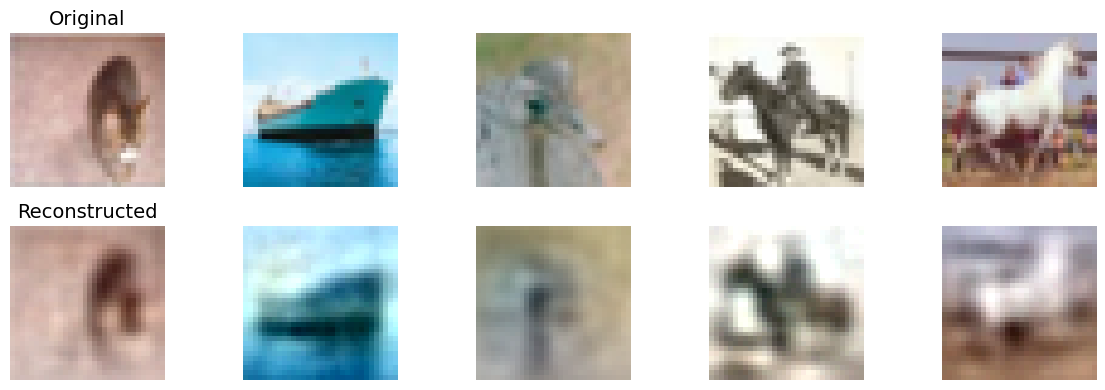

AE Epoch 18: 100%|██████████| 313/313 [00:13<00:00, 22.83it/s]


AE Epoch [18/20] Train Loss: 0.0284, Val Loss: 0.0283


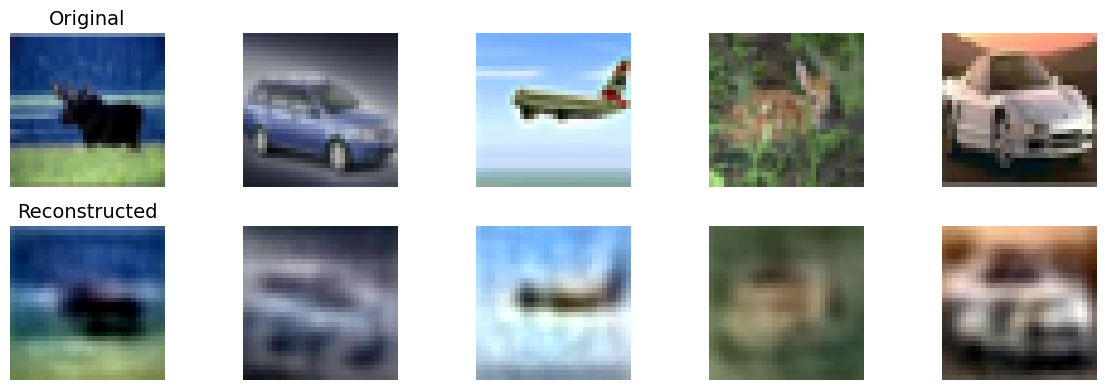

AE Epoch 19: 100%|██████████| 313/313 [00:13<00:00, 23.04it/s]


AE Epoch [19/20] Train Loss: 0.0282, Val Loss: 0.0293


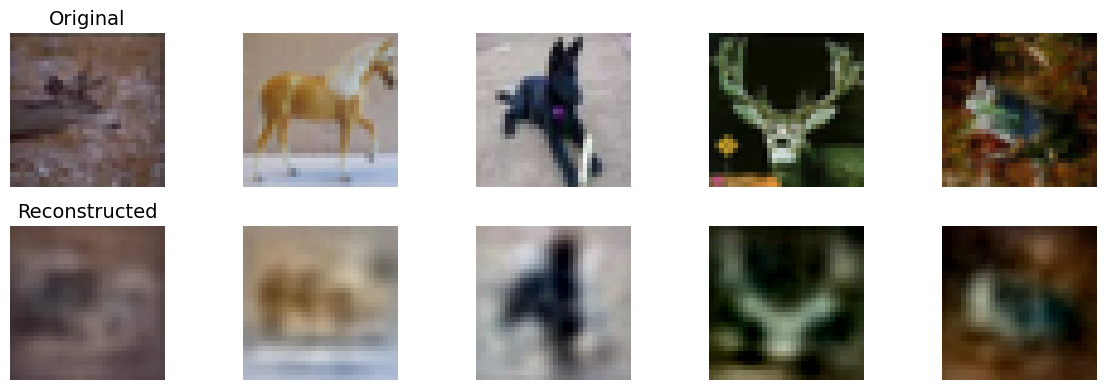

AE Epoch 20: 100%|██████████| 313/313 [00:14<00:00, 21.97it/s]


AE Epoch [20/20] Train Loss: 0.0279, Val Loss: 0.0278


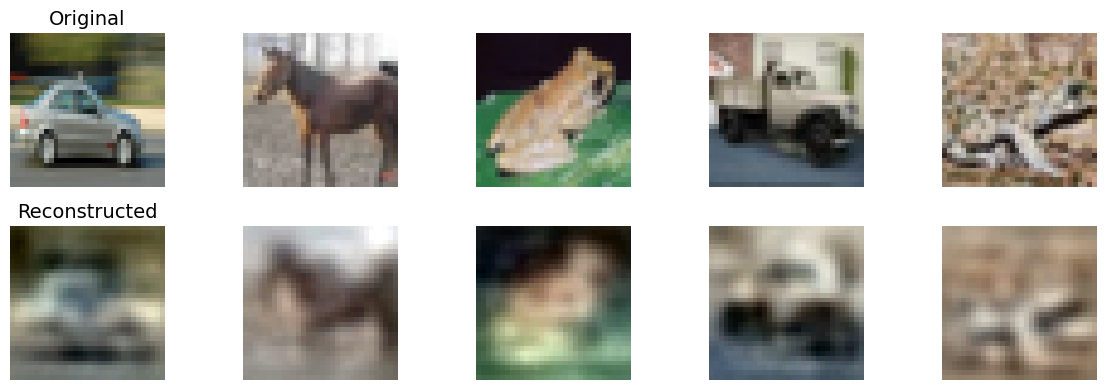

Model saved to use_cifar_autoencoder.pth


In [8]:
import os
import torch

# Define the file path
model_path = "use_cifar_autoencoder.pth"

# Initialize the autoencoder model
ae = Autoencoder(cfg['input_channels'], cfg['input_size']).to(device)

# Check if the model file exists
if os.path.exists(model_path):
    print(f"Loading pre-trained model from {model_path}")
    ae.load_state_dict(torch.load(model_path))
    ae.eval()  # Set the model to evaluation mode
else:
    print(f"Training Autoencoder on {dataset_name}")
    ae = train_autoencoder(ae, train_loader, val_loader, device, num_epochs_ae, dataset_name)
    # Save the trained model
    torch.save(ae.state_dict(), model_path)
    print(f"Model saved to {model_path}")

In [10]:
ae_test_loss = evaluate(ae, test_loader, device, criterion = nn.MSELoss())
print(f'Test Loss: {ae_test_loss:.4f}')

Test Loss: 0.0278


In [33]:
# Classifier

classifier = Classifier(ae.encoder, input_channels=3, input_size=32, num_classes=10).to(device)
# classifier = Classifier(ae.encoder, config[dataset_name]['num_classes']).to(device)

for param in classifier.encoder.parameters():
    param.requires_grad = False
print(f"\nTraining Classifier on {dataset_name}")
classifier = train_classifier(classifier, train_loader, val_loader, device, num_epochs_cls, dataset_name)


Training Classifier on CIFAR10


CLS Epoch 1: 100%|██████████| 313/313 [00:14<00:00, 21.67it/s]


CLS Epoch [1/50] Train Loss: 1.7150, Val Acc: 43.85%


CLS Epoch 2: 100%|██████████| 313/313 [00:14<00:00, 21.98it/s]


CLS Epoch [2/50] Train Loss: 1.5362, Val Acc: 48.10%


...

CLS Epoch [24/50] Train Loss: 0.8611, Val Acc: 57.94%


CLS Epoch 25: 100%|██████████| 313/313 [00:14<00:00, 22.25it/s]


CLS Epoch [25/50] Train Loss: 0.8389, Val Acc: 58.13%


CLS Epoch 26: 100%|██████████| 313/313 [00:14<00:00, 21.77it/s]


CLS Epoch [26/50] Train Loss: 0.8165, Val Acc: 58.53%
Early stopping triggered


In [34]:

# Final test
test_acc = evaluate_classifier(classifier, test_loader, device)
print(f'\nFinal Test Accuracy on {dataset_name}: {test_acc:.2f}%')



Final Test Accuracy on CIFAR10: 58.98%


In [41]:
# Visualization
plot_tsne(ae.encoder, test_loader, device)

In [ ]:
###############################################